In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json
import warnings

warnings.simplefilter(action='ignore', category=Warning)

fsize = 10
plt.rcParams.update({"font.size": fsize})
%config InlineBackend.figure_format = 'retina'

# Extraction vs Generation

Provenance notebook for `results_generation.tex` and `table_generation.tex`.

Compares three evidence sources against human curation:
- **Extraction** (`evidence_llm`): marker genes extracted from manuscript text
- **Generation** (`evidence_generated`): marker genes generated from cell type names (celltypes-to-genes)
- **Prediction** (`evidence_predicted`): cell types predicted from anonymized gene groups (genes-to-celltypes)

# Load data

In [2]:
datasets = [
    "adipose_Emont2022",
    "adipose_Hildreth2021",
    "bone_He2021",
    "eye_Gautam2021",
    "lung_Adams2020",
    "ovary_Wagner2020",
    "testis_Shamis2020",
]

labels = {
    "adipose_Emont2022": "Adipose (Emont)",
    "adipose_Hildreth2021": "Adipose (Hildreth)",
    "bone_He2021": "Bone (He)",
    "eye_Gautam2021": "Eye (Gautam)",
    "lung_Adams2020": "Lung (Adams)",
    "ovary_Wagner2020": "Ovary (Wagner)",
    "testis_Shamis2020": "Testis (Shamis)",
}

data = {}
for ds in datasets:
    hmn = pd.read_json(f"../data/{ds}/evidence_human/extracted.json")
    llm = pd.read_json(f"../data/{ds}/evidence_llm/extracted_txt.json")
    gen = pd.read_json(f"../data/{ds}/evidence_generated/extracted.json")
    pred = pd.read_json(f"../data/{ds}/evidence_predicted/extracted.json")

    # normalize
    for df in [hmn, llm, gen, pred]:
        df["group_name"] = df["group_name"].str.strip().str.upper()
        df["feature_name"] = df["feature_name"].str.strip().str.upper()

    data[ds] = {"hmn": hmn, "llm": llm, "gen": gen, "pred": pred}
    print(f"{ds}: hmn={len(hmn)}, llm={len(llm)}, gen={len(gen)}, pred={len(pred)}")

adipose_Emont2022: hmn=387, llm=40, gen=317, pred=346
adipose_Hildreth2021: hmn=301, llm=59, gen=252, pred=241
bone_He2021: hmn=825, llm=48, gen=203, pred=378
eye_Gautam2021: hmn=514, llm=51, gen=244, pred=251
lung_Adams2020: hmn=147, llm=53, gen=165, pred=135
ovary_Wagner2020: hmn=139, llm=35, gen=69, pred=58
testis_Shamis2020: hmn=215, llm=95, gen=144, pred=186


# Helpers

In [3]:
def build_pairs(df):
    """Build set of (group_name, feature_id) pairs."""
    pairs = set()
    for _, r in df.iterrows():
        gn = r.get("group_name")
        fn = r.get("feature_id")
        if pd.notna(gn) and pd.notna(fn) and gn and fn:
            pairs.add((gn, fn))
    return pairs


def build_groups(df):
    """Build dict of group_name -> set of feature_ids."""
    groups = {}
    for _, r in df.iterrows():
        gn = r.get("group_name")
        fn = r.get("feature_id")
        if pd.notna(gn) and pd.notna(fn) and gn and fn:
            groups.setdefault(gn, set()).add(fn)
    return groups


def gene_set(df):
    """Get unique feature_ids."""
    return set(df["feature_id"].dropna().unique())


def pair_f1(pairs_a, pairs_b):
    """Precision, recall, F1 of pairs_a vs pairs_b (b = reference)."""
    if not pairs_a and not pairs_b:
        return 0, 0, 0
    tp = len(pairs_a & pairs_b)
    p = tp / len(pairs_a) if pairs_a else 0
    r = tp / len(pairs_b) if pairs_b else 0
    f = 2 * p * r / (p + r) if (p + r) > 0 else 0
    return p, r, f


def per_celltype_gene_f1(groups_a, groups_b):
    """Mean per-cell-type gene F1 over shared cell types."""
    shared = set(groups_a) & set(groups_b)
    if not shared:
        return 0, 0
    f1s = []
    for ct in shared:
        a, b = groups_a[ct], groups_b[ct]
        tp = len(a & b)
        p = tp / len(a) if a else 0
        r = tp / len(b) if b else 0
        f = 2 * p * r / (p + r) if (p + r) > 0 else 0
        f1s.append(f)
    return np.mean(f1s), len(shared)


def gene_jaccard(groups_a, groups_b):
    """Jaccard of unique gene sets (ignoring cell type)."""
    ga = set(fn for fns in groups_a.values() for fn in fns)
    gb = set(fn for fns in groups_b.values() for fn in fns)
    union = ga | gb
    return len(ga & gb) / len(union) if union else 0

# Table: Extraction vs Generation (Table 1 in tex)

In [4]:
rows = []
for ds in datasets:
    d = data[ds]
    hmn_g = build_groups(d["hmn"])
    llm_g = build_groups(d["llm"])
    gen_g = build_groups(d["gen"])

    n_ct = len(hmn_g)
    ext_f1, ext_shared = per_celltype_gene_f1(llm_g, hmn_g)
    gen_f1, gen_shared = per_celltype_gene_f1(gen_g, hmn_g)
    ext_jacc = gene_jaccard(llm_g, hmn_g)
    gen_jacc = gene_jaccard(gen_g, hmn_g)

    # prediction accuracy
    pred_df = d["pred"]
    preds = {}
    for _, r in pred_df.iterrows():
        orig = r.get("_original_group_name", "")
        predicted = r.get("group_name", "")
        if orig and predicted and orig not in preds:
            preds[orig] = predicted
    n_groups = len(preds)
    n_exact = sum(1 for o, p in preds.items() if o == p)

    rows.append({
        "dataset": labels[ds],
        "cell_types": n_ct,
        "ext_f1": ext_f1,
        "gen_f1": gen_f1,
        "ext_jaccard": ext_jacc,
        "gen_jaccard": gen_jacc,
        "pred_exact": n_exact,
        "pred_total": n_groups,
    })

tbl = pd.DataFrame(rows)
tbl

,dataset,cell_types,ext_f1,gen_f1,ext_jaccard,gen_jaccard,pred_exact,pred_total
0,Adipose (Emont),45,0.368878,0.171822,0.221239,0.098246,6,45
1,Adipose (Hildreth),31,0.518879,0.286010,0.315068,0.250996,3,31
2,Bone (He),27,0.436606,0.152235,0.362500,0.163043,1,27
3,Eye (Gautam),32,0.324807,0.176231,0.192982,0.175439,4,32
4,Lung (Adams),20,0.582849,0.245425,0.253623,0.213636,8,20
5,Ovary (Wagner),7,0.590329,0.270981,0.509434,0.206186,2,7
6,Testis (Shamis),19,0.661999,0.274086,0.542636,0.193548,3,19


In [5]:
# Summary row
print("Means across datasets:")
print(f"  Extraction Gene F1:  {tbl['ext_f1'].mean():.2f}")
print(f"  Generation Gene F1:  {tbl['gen_f1'].mean():.2f}")
print(f"  Extraction Jaccard:  {tbl['ext_jaccard'].mean():.2f}")
print(f"  Generation Jaccard:  {tbl['gen_jaccard'].mean():.2f}")
print(f"  Prediction accuracy: {tbl['pred_exact'].sum()}/{tbl['pred_total'].sum()} "
      f"({tbl['pred_exact'].sum()/tbl['pred_total'].sum():.0%})")

Means across datasets:
  Extraction Gene F1:  0.50
  Generation Gene F1:  0.23
  Extraction Jaccard:  0.34
  Generation Jaccard:  0.19
  Prediction accuracy: 27/181 (15%)


# Per-cell-type Gene F1 detail

In [6]:
ct_rows = []
for ds in datasets:
    d = data[ds]
    hmn_g = build_groups(d["hmn"])
    llm_g = build_groups(d["llm"])
    gen_g = build_groups(d["gen"])

    all_cts = sorted(set(hmn_g) | set(llm_g) | set(gen_g))
    for ct in all_cts:
        h = hmn_g.get(ct, set())
        e = llm_g.get(ct, set())
        g = gen_g.get(ct, set())

        def _f1(a, b):
            tp = len(a & b)
            p = tp / len(a) if a else 0
            r = tp / len(b) if b else 0
            return 2 * p * r / (p + r) if (p + r) > 0 else 0

        ct_rows.append({
            "dataset": labels[ds],
            "cell_type": ct,
            "n_hmn": len(h),
            "n_ext": len(e),
            "n_gen": len(g),
            "ext_f1": _f1(e, h) if h and e else np.nan,
            "gen_f1": _f1(g, h) if h and g else np.nan,
        })

ct_df = pd.DataFrame(ct_rows)
ct_df.head(20)

,dataset,cell_type,n_hmn,n_ext,n_gen,ext_f1,gen_f1
0,Adipose (Emont),ADIPOCYTE,1,2,9,0.666667,0.200000
1,Adipose (Emont),ADIPOCYTE 1,38,4,7,0.047619,0.222222
2,Adipose (Emont),ADIPOCYTE 2,35,0,7,NaN,0.190476
3,Adipose (Emont),ADIPOCYTE 3,29,4,6,0.242424,0.171429
4,Adipose (Emont),ADIPOCYTE 4,46,3,6,0.081633,0.192308
5,Adipose (Emont),ADIPOCYTE 5,29,4,6,0.181818,0.171429
6,Adipose (Emont),ADIPOCYTE 6,38,3,6,0.146341,0.181818
7,Adipose (Emont),ADIPOCYTE 7,38,1,6,0.000000,0.136364
8,Adipose (Emont),ADIPOSE STEM AND PROGENITOR CELL,0,1,0,NaN,NaN
9,Adipose (Emont),ADIPOSE STEM AND PROGENITOR CELL 1,2,0,8,NaN,0.200000


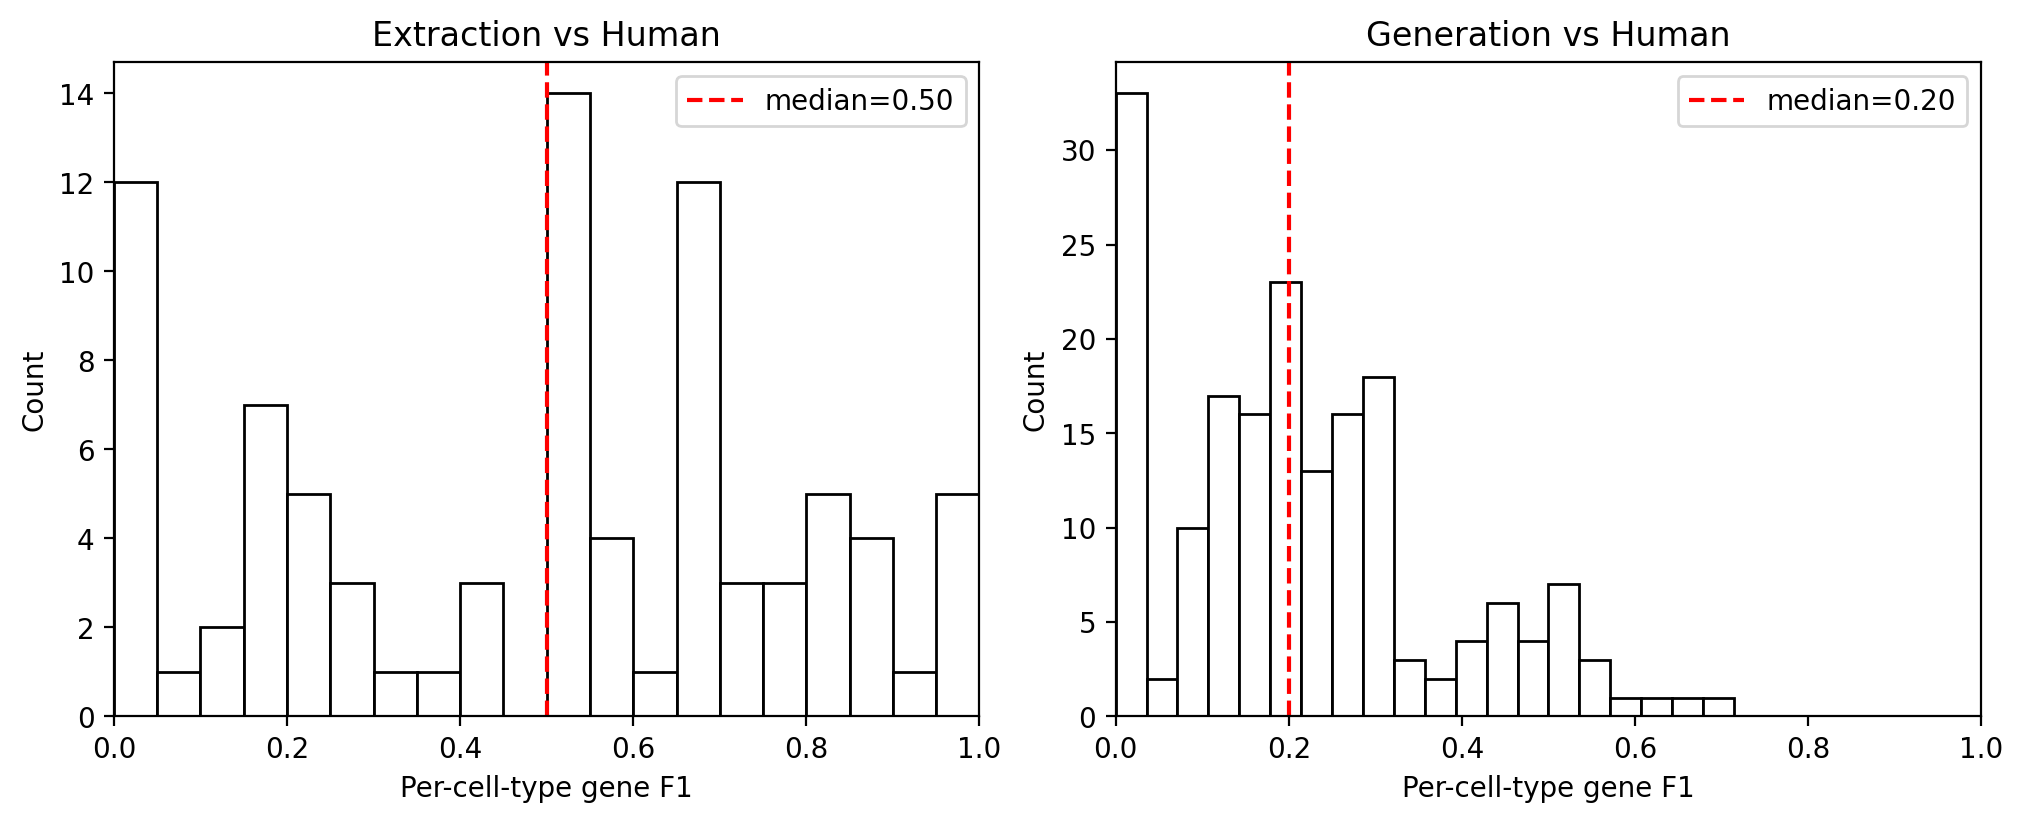

In [7]:
# Distribution of per-cell-type F1
fig, axs = plt.subplots(figsize=(10, 4), ncols=2, constrained_layout=True)

for ax, col, title in zip(axs, ["ext_f1", "gen_f1"], ["Extraction", "Generation"]):
    vals = ct_df[col].dropna()
    ax.hist(vals, bins=20, edgecolor="k", facecolor="white")
    ax.axvline(vals.median(), color="red", linestyle="--", label=f"median={vals.median():.2f}")
    ax.set(**{
        "xlabel": "Per-cell-type gene F1",
        "ylabel": "Count",
        "title": f"{title} vs Human",
        "xlim": (0, 1),
    })
    ax.legend()

plt.show()

# Gene-level Jaccard detail

In [8]:
jacc_rows = []
for ds in datasets:
    d = data[ds]
    hmn_g = build_groups(d["hmn"])
    llm_g = build_groups(d["llm"])
    gen_g = build_groups(d["gen"])

    # Use genes from build_groups (consistent with gene_jaccard in tbl)
    h_genes = set(fn for fns in hmn_g.values() for fn in fns)
    e_genes = set(fn for fns in llm_g.values() for fn in fns)
    g_genes = set(fn for fns in gen_g.values() for fn in fns)

    jacc_rows.append({
        "dataset": labels[ds],
        "hmn_genes": len(h_genes),
        "ext_genes": len(e_genes),
        "gen_genes": len(g_genes),
        "ext_shared": len(e_genes & h_genes),
        "gen_shared": len(g_genes & h_genes),
        "ext_jaccard": len(e_genes & h_genes) / len(e_genes | h_genes) if (e_genes | h_genes) else 0,
        "gen_jaccard": len(g_genes & h_genes) / len(g_genes | h_genes) if (g_genes | h_genes) else 0,
    })

jacc_df = pd.DataFrame(jacc_rows)
jacc_df

,dataset,hmn_genes,ext_genes,gen_genes,ext_shared,gen_shared,ext_jaccard,gen_jaccard
0,Adipose (Emont),105,33,208,25,28,0.221239,0.098246
1,Adipose (Hildreth),141,51,173,46,63,0.315068,0.250996
2,Bone (He),75,34,139,29,30,0.362500,0.163043
3,Eye (Gautam),92,44,176,22,40,0.192982,0.175439
4,Lung (Adams),124,49,143,35,47,0.253623,0.213636
5,Ovary (Wagner),50,30,67,27,20,0.509434,0.206186
6,Testis (Shamis),125,74,97,70,36,0.542636,0.193548


# Genes-to-celltypes prediction detail

In [9]:
pred_rows = []
for ds in datasets:
    d = data[ds]
    pred_df = d["pred"]

    preds = {}
    for _, r in pred_df.iterrows():
        orig = r.get("_original_group_name", "")
        predicted = r.get("group_name", "")
        if orig and predicted and orig not in preds:
            preds[orig] = predicted

    for orig, predicted in sorted(preds.items()):
        # categorize match quality
        if orig == predicted:
            match = "exact"
        elif orig.lower() in predicted.lower() or predicted.lower() in orig.lower():
            match = "contains"
        elif set(orig.lower().split()) & set(predicted.lower().split()):
            match = "partial"
        else:
            match = "none"

        pred_rows.append({
            "dataset": labels[ds],
            "original": orig,
            "predicted": predicted,
            "match": match,
        })

pred_detail = pd.DataFrame(pred_rows)
pred_detail.head(20)

,dataset,original,predicted,match
0,Adipose (Emont),ADIPOCYTE,ADIPOCYTE,exact
1,Adipose (Emont),ADIPOCYTE 1,MATURE WHITE ADIPOCYTE,partial
2,Adipose (Emont),ADIPOCYTE 2,MHC-II-EXPRESSING ADIPOCYTE,partial
3,Adipose (Emont),ADIPOCYTE 3,MATURE WHITE ADIPOCYTE,partial
4,Adipose (Emont),ADIPOCYTE 4,LIPOGENIC ADIPOCYTE,partial
5,Adipose (Emont),ADIPOCYTE 5,MATURE WHITE ADIPOCYTE,partial
6,Adipose (Emont),ADIPOCYTE 6,BEIGE/BRITE ADIPOCYTE,partial
7,Adipose (Emont),ADIPOCYTE 7,MATURE ADIPOCYTE,partial
8,Adipose (Emont),ADIPOSE STEM AND PROGENITOR CELL 1,ADIPOCYTE PROGENITOR CELL,partial
9,Adipose (Emont),ADIPOSE STEM AND PROGENITOR CELL 2,ADIPOSE-DERIVED STEM CELL,partial


In [10]:
# Prediction match quality by dataset
pred_summary = pred_detail.groupby(["dataset", "match"]).size().unstack(fill_value=0)
pred_summary = pred_summary.reindex(columns=["exact", "contains", "partial", "none"], fill_value=0)
pred_summary["total"] = pred_summary.sum(axis=1)
pred_summary["accuracy"] = pred_summary["exact"] / pred_summary["total"]
pred_summary

match,exact,contains,partial,none,total,accuracy
dataset,,,,,,
Adipose (Emont),6,2,22,15,45,0.133333
Adipose (Hildreth),3,4,14,10,31,0.096774
Bone (He),1,1,16,9,27,0.037037
Eye (Gautam),4,4,15,9,32,0.125000
Lung (Adams),8,2,10,0,20,0.400000
Ovary (Wagner),2,1,3,1,7,0.285714
Testis (Shamis),3,4,6,6,19,0.157895


In [11]:
# Totals
totals = pred_summary.drop(columns="accuracy").sum()
totals["accuracy"] = totals["exact"] / totals["total"]
print("Overall prediction totals:")
print(totals)
print(f"\nSemantically close (exact+contains+partial): "
      f"{int(totals['exact'] + totals['contains'] + totals['partial'])}/{int(totals['total'])} "
      f"({(totals['exact'] + totals['contains'] + totals['partial'])/totals['total']:.0%})")

Overall prediction totals:
match
exact        27.000000
contains     18.000000
partial      86.000000
none         50.000000
total       181.000000
accuracy      0.149171
dtype: float64

Semantically close (exact+contains+partial): 131/181 (72%)


# Summary for tex table

In [12]:
# Print the table values that go into table_generation.tex
print(f"{'Dataset':<22} {'CTs':>4} {'Ext F1':>7} {'Gen F1':>7} {'Ext J':>6} {'Gen J':>6} {'Pred':>8}")
print("-" * 65)
for _, r in tbl.iterrows():
    print(f"{r['dataset']:<22} {r['cell_types']:>4} {r['ext_f1']:>7.2f} {r['gen_f1']:>7.2f} "
          f"{r['ext_jaccard']:>6.2f} {r['gen_jaccard']:>6.2f} "
          f"{r['pred_exact']:>3}/{r['pred_total']:<3}")
print("-" * 65)
print(f"{'Mean':<22} {'':>4} {tbl['ext_f1'].mean():>7.2f} {tbl['gen_f1'].mean():>7.2f} "
      f"{tbl['ext_jaccard'].mean():>6.2f} {tbl['gen_jaccard'].mean():>6.2f} "
      f"{tbl['pred_exact'].sum():>3}/{tbl['pred_total'].sum():<3}")

Dataset                 CTs  Ext F1  Gen F1  Ext J  Gen J     Pred
-----------------------------------------------------------------
Adipose (Emont)          45    0.37    0.17   0.22   0.10   6/45 
Adipose (Hildreth)       31    0.52    0.29   0.32   0.25   3/31 
Bone (He)                27    0.44    0.15   0.36   0.16   1/27 
Eye (Gautam)             32    0.32    0.18   0.19   0.18   4/32 
Lung (Adams)             20    0.58    0.25   0.25   0.21   8/20 
Ovary (Wagner)            7    0.59    0.27   0.51   0.21   2/7  
Testis (Shamis)          19    0.66    0.27   0.54   0.19   3/19 
-----------------------------------------------------------------
Mean                           0.50    0.23   0.34   0.19  27/181
